=== Dataset Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7845 entries, 0 to 7844
Data columns (total 24 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Updated On                           7845 non-null   object 
 1   State                                7845 non-null   object 
 2   Total Doses Administered             7621 non-null   float64
 3   Sessions                             7621 non-null   float64
 4    Sites                               7621 non-null   float64
 5   First Dose Administered              7621 non-null   float64
 6   Second Dose Administered             7621 non-null   float64
 7   Male (Doses Administered)            7461 non-null   float64
 8   Female (Doses Administered)          7461 non-null   float64
 9   Transgender (Doses Administered)     7461 non-null   float64
 10   Covaxin (Doses Administered)        7621 non-null   float64
 11  Co

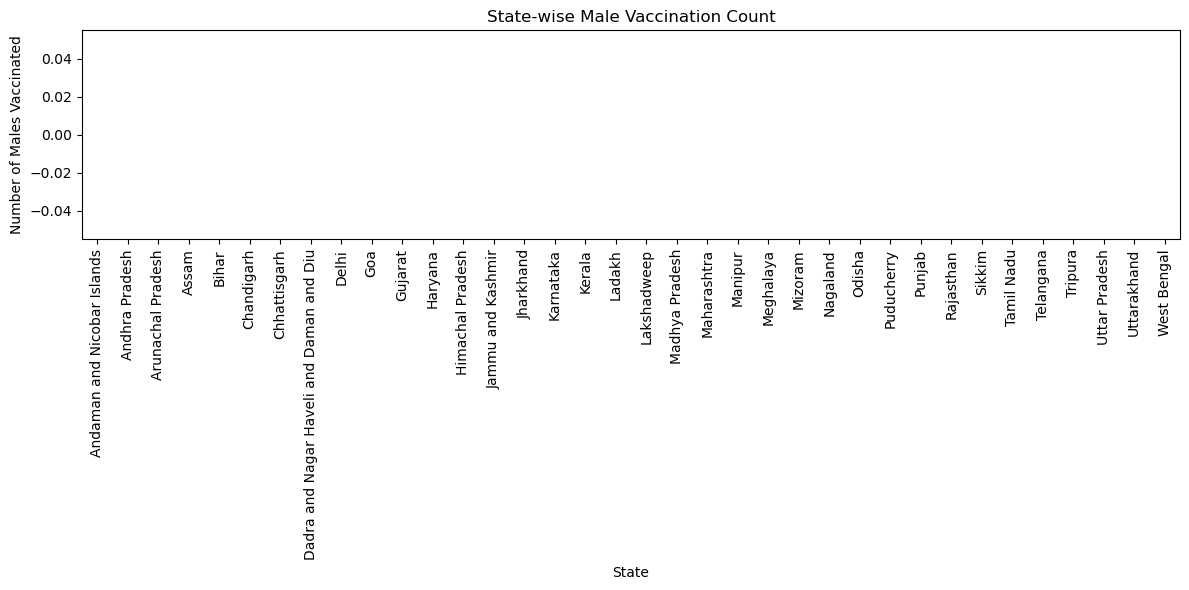

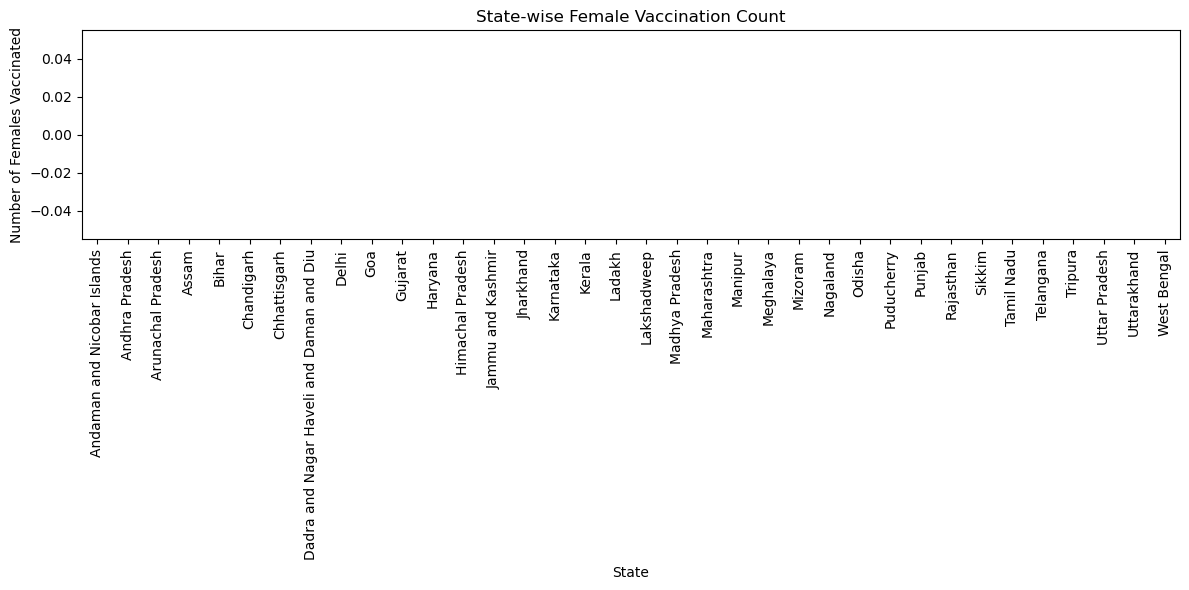

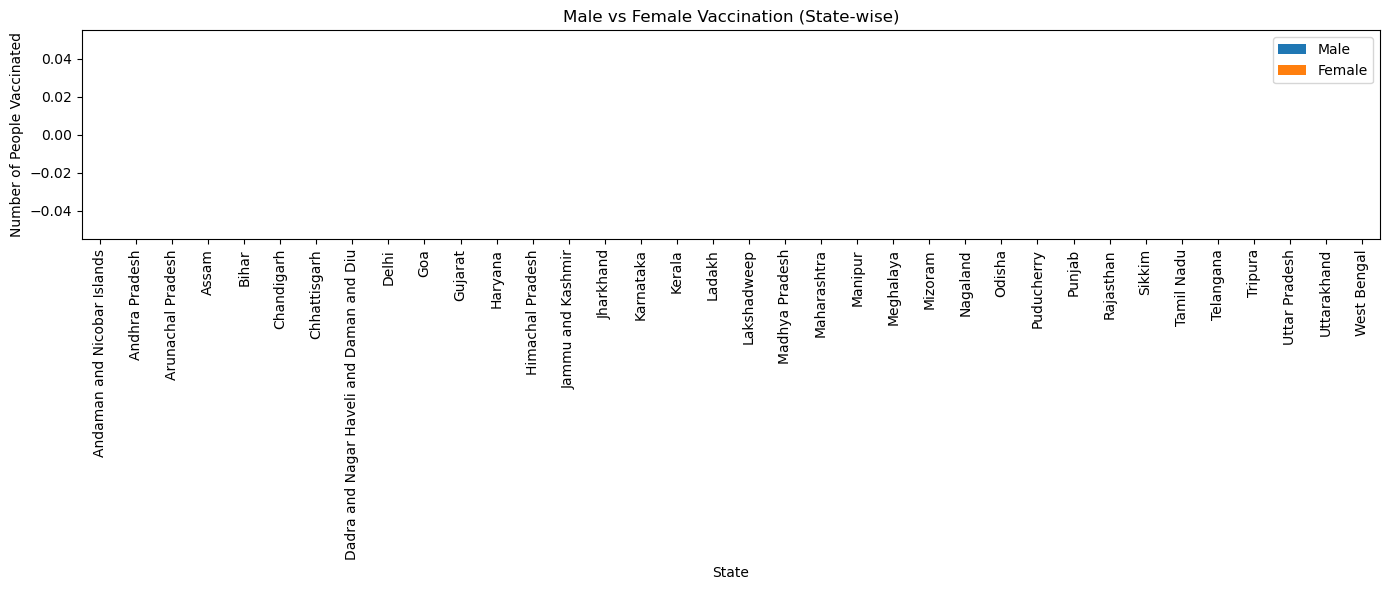

In [9]:
# Practical 14 – COVID Vaccine Statewise Analysis (Male & Female)
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------
# A. Load & Describe Dataset
# -------------------------------------------
df = pd.read_csv("Covid Vaccine Statewise.csv")

print("=== Dataset Information ===")
print(df.info())

print("\n=== Dataset Summary ===")
print(df.describe(include='all'))

# -------------------------------------------
# Data Cleaning
# -------------------------------------------

# Use correct column names present in your dataset
male_col = "Male(Individuals Vaccinated)"
female_col = "Female(Individuals Vaccinated)"

# Replace missing values with 0
df[male_col] = df[male_col].fillna(0)
df[female_col] = df[female_col].fillna(0)

# Remove national-level "India" row to keep only states
df_states = df[df["State"] != "India"]

# -------------------------------------------
# B. Number of Males Vaccinated (State-wise)
# -------------------------------------------
male_statewise = df_states.groupby("State")[male_col].sum()
print("\n=== State-wise Male Vaccinations ===")
print(male_statewise)

# -------------------------------------------
# C. Number of Females Vaccinated (State-wise)
# -------------------------------------------
female_statewise = df_states.groupby("State")[female_col].sum()
print("\n=== State-wise Female Vaccinations ===")
print(female_statewise)

# -------------------------------------------
# Visualization 1 – Male Vaccination
# -------------------------------------------
male_statewise.plot(kind="bar", figsize=(12, 6), color="blue")
plt.title("State-wise Male Vaccination Count")
plt.xlabel("State")
plt.ylabel("Number of Males Vaccinated")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# -------------------------------------------
# Visualization 2 – Female Vaccination
# -------------------------------------------
female_statewise.plot(kind="bar", figsize=(12, 6), color="orange")
plt.title("State-wise Female Vaccination Count")
plt.xlabel("State")
plt.ylabel("Number of Females Vaccinated")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# -------------------------------------------
# Visualization 3 – Combined Male vs Female
# -------------------------------------------
combined = pd.DataFrame({
    "Male": male_statewise,
    "Female": female_statewise
})

combined.plot(kind="bar", figsize=(14, 6))
plt.title("Male vs Female Vaccination (State-wise)")
plt.xlabel("State")
plt.ylabel("Number of People Vaccinated")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
